##  Parisagbp _Mini project2 _ Question4

## Imports

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# https://drive.google.com/file/d/1bEwk9gWmpIaAXfPa8yj7Cag0j8NH0Rr_/view?usp=sharing
!pip install --upgrade --no-cache-dir gdown
!gdown 1bEwk9gWmpIaAXfPa8yj7Cag0j8NH0Rr_

  Attempting uninstall: gdown
    Found existing installation: gdown 5.1.0
    Uninstalling gdown-5.1.0:
      Successfully uninstalled gdown-5.1.0
Downloading...
From: https://drive.google.com/uc?id=1bEwk9gWmpIaAXfPa8yj7Cag0j8NH0Rr_
To: /content/heart.csv
100% 38.1k/38.1k [00:00<00:00, 60.6MB/s]


In [3]:
import pandas as pd
Data = pd.read_csv('/content/heart.csv')
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [4]:
Data

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [5]:
Data.groupby('target').size()

target
0    499
1    526
dtype: int64

<Axes: xlabel='target', ylabel='count'>

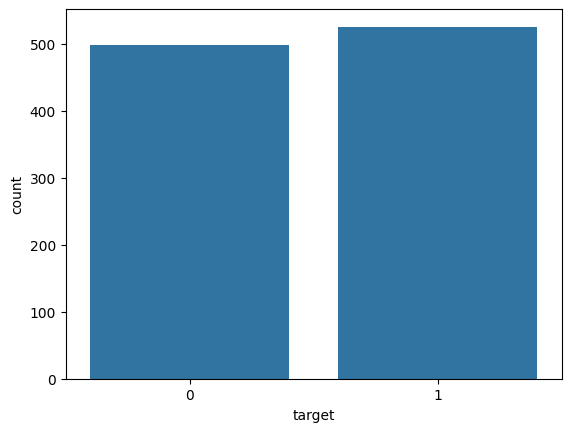

In [6]:
sns.countplot(x='target', data=Data)

## Pre_processing

In [7]:
for i in Data.columns:
 print('Number of NaN in',i,'=',Data.isna().sum().sum())

Number of NaN in age = 0
Number of NaN in sex = 0
Number of NaN in cp = 0
Number of NaN in trestbps = 0
Number of NaN in chol = 0
Number of NaN in fbs = 0
Number of NaN in restecg = 0
Number of NaN in thalach = 0
Number of NaN in exang = 0
Number of NaN in oldpeak = 0
Number of NaN in slope = 0
Number of NaN in ca = 0
Number of NaN in thal = 0
Number of NaN in target = 0


## Shuffle and Spliting Data

In [8]:
import pandas as pd
import numpy as np
np.random.seed(64)

array = Data.values  #  numpy array
np.random.shuffle(array)  # Shuffle the array
shdata = pd.DataFrame(array, columns=Data.columns)
shdata

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,65.0,1.0,0.0,110.0,248.0,0.0,0.0,158.0,0.0,0.6,2.0,2.0,1.0,0.0
1,52.0,0.0,2.0,136.0,196.0,0.0,0.0,169.0,0.0,0.1,1.0,0.0,2.0,1.0
2,45.0,1.0,3.0,110.0,264.0,0.0,1.0,132.0,0.0,1.2,1.0,0.0,3.0,0.0
3,53.0,1.0,0.0,123.0,282.0,0.0,1.0,95.0,1.0,2.0,1.0,2.0,3.0,0.0
4,60.0,0.0,2.0,102.0,318.0,0.0,1.0,160.0,0.0,0.0,2.0,1.0,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,55.0,1.0,0.0,140.0,217.0,0.0,1.0,111.0,1.0,5.6,0.0,0.0,3.0,0.0
1021,56.0,1.0,0.0,132.0,184.0,0.0,0.0,105.0,1.0,2.1,1.0,1.0,1.0,0.0
1022,42.0,1.0,1.0,120.0,295.0,0.0,1.0,162.0,0.0,0.0,2.0,0.0,2.0,1.0
1023,42.0,1.0,0.0,136.0,315.0,0.0,1.0,125.0,1.0,1.8,1.0,0.0,1.0,0.0


Test and train data

In [10]:
from sklearn.model_selection import train_test_split
# train_data, test_data, train_label, test_label = train_test_split(shdata.drop(['target'], axis=1), shdata['target'], test_size=0.2, random_state=64)
X_train,X_test,y_train,y_test=train_test_split(shdata.drop(['target'], axis=1), shdata['target'],test_size=0.2,random_state=64)
print('train:',X_train.shape, y_train.shape,'\ntest: ', X_test.shape, y_test.shape)


train: (820, 13) (820,) 
test:  (205, 13) (205,)


##StandardScaler

In [29]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
# scale the test data using the same scaler used for training data
X_test = scaler.transform(X_test)
y_train=y_train
y_test=y_test
print('train:',X_train.shape, y_train.shape,'\ntest: ', X_test.shape, y_test.shape)

train: (820, 13) (820,) 
test:  (205, 13) (205,)


##**NaiveBayes Classifier**

In [24]:
from sklearn.naive_bayes import GaussianNB
SKNB=GaussianNB()
SKNB.fit(X_train,y_train)
predicted = SKNB.predict(X_test)
predicted

array([0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 1., 1., 0., 0., 0., 1., 1.,
       0., 0., 1., 1., 1., 1., 0., 0., 1., 1., 0., 1., 1., 0., 0., 0., 1.,
       0., 0., 1., 0., 1., 0., 1., 0., 1., 1., 0., 0., 0., 1., 0., 1., 0.,
       0., 1., 0., 1., 1., 0., 1., 1., 1., 0., 1., 1., 0., 1., 1., 0., 1.,
       0., 1., 1., 0., 0., 1., 1., 0., 1., 0., 0., 0., 1., 0., 1., 1., 0.,
       1., 1., 1., 1., 0., 1., 1., 1., 1., 0., 0., 1., 0., 1., 0., 0., 0.,
       0., 1., 1., 1., 1., 1., 0., 1., 0., 0., 1., 1., 1., 0., 1., 1., 0.,
       0., 1., 0., 1., 1., 0., 1., 0., 0., 1., 0., 1., 0., 0., 1., 1., 0.,
       0., 1., 1., 0., 0., 1., 1., 1., 0., 1., 1., 0., 0., 0., 0., 0., 1.,
       0., 1., 1., 1., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 1., 0., 0.,
       1., 1., 0., 1., 0., 1., 0., 0., 1., 1., 0., 0., 1., 0., 1., 1., 1.,
       0., 1., 1., 1., 0., 0., 0., 0., 1., 1., 0., 1., 0., 1., 1., 0., 1.,
       1.])

##Evaluation

###confusion_matrix

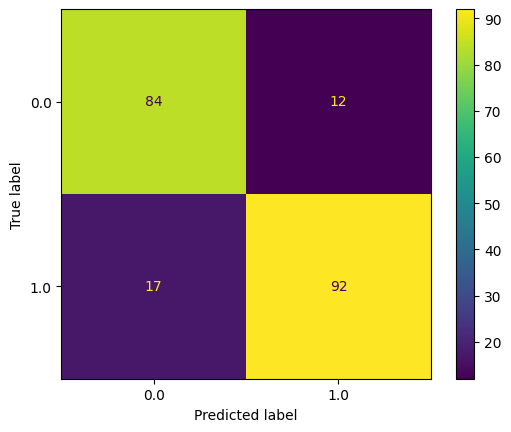

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test,predicted)
names = list(shdata.groupby('target').groups.keys())
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=names)
disp.plot()
plt.show()

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print('Accuracy :',accuracy_score(y_test,predicted))
print('Precision :',precision_score(y_test,predicted))
print('Recall :',recall_score(y_test,predicted))
print('F1 score :',f1_score(y_test,predicted))

Accuracy : 0.8585365853658536
Precision : 0.8846153846153846
Recall : 0.8440366972477065
F1 score : 0.863849765258216


####micro & macro

In [26]:
print('Precision_micro :',precision_score(y_test,pred,average='micro'))
print('Precision_macro :',precision_score(y_test,pred,average='macro'))

print('Recall_micro :',recall_score(y_test,pred,average='micro'))
print('Recall_macro :',recall_score(y_test,pred,average='macro'))

print('F1 score_micro :',f1_score(y_test,pred,average='micro'))
print('F1 score_macro :',f1_score(y_test,pred,average='macro'))

Precision_micro : 0.8585365853658536
Precision_macro : 0.8581492764661081
Recall_micro : 0.8585365853658536
Recall_macro : 0.8595183486238532
F1 score_micro : 0.8585365853658536
F1 score_macro : 0.8583208217154024


###classification_report

In [28]:
from sklearn.metrics import classification_report
print(classification_report(y_test,predicted))

              precision    recall  f1-score   support

         0.0       0.83      0.88      0.85        96
         1.0       0.88      0.84      0.86       109

    accuracy                           0.86       205
   macro avg       0.86      0.86      0.86       205
weighted avg       0.86      0.86      0.86       205

